# Image Classification using Hand-Crafted Features 

This project aims to build a robust image classification solution for the TinyImageNet100 dataset.  <sup>1</sup>

We evaluate multiple approaches to develop the optimal model:
-  **Local Features**: SIFT (Scale-Invariant Feature Transform)<sup>2</sup> vs. ORB (Oriented FAST and Rotated BRIEF)<sup>3</sup>.
-  **Encoding Methods**: Bag of Words (BoW)<sup>4</sup> vs. Fisher Vectors (FV)<sup>5</sup>.
-  **Classification**: Support Vector Machines (SVM)<sup>6</sup> with hyperparameter tuning.

The ultimate goal is to identify the correct class of an image from a random sample of 15 classes.

A defining feature of TinyImageNet100 is the compressed, cropped nature of the images to reduce them down to a relatively 'tiny' size of 64x64 vs. the standard images of 500x500 these local feature extraction methods were trained on. This creates a lot of noise, obscures a lot of detail and makes local feature extraction much more challenging. 

A naive implementation of these algorithms with their default paramaters produces results that are barely better than chance (1 in 15, or 6.7%). We leave in the ORB baseline setting for a comparison: it fails to detect a single feature in most photos.

SIFT combined with Fisher Vectors were established as the state-of-the-art before Deep Learning become the dominant form of image classification. It is also the top performer in this evaluation, but this particular implementation involves a number of unconventional choices to achieve that.

In a choice between few highly distinctive features and many overlapping features, typical best practice is to opt for the few highly distinctive features. In our case there are just too few highly distinctive features to be practically useful, so we need to increase the detection of semi-distinct features at the cost of detecting some pure noise too. In particular that meant changing the parameters as follows:

Parameter | Default Value | Value Used | Impact |
----------|---------------|------------|--------|
nOctaveLayers| 3 | 5 | Denser scale-space sampling, capturing more overlapping keypoints | 
contrastTreshold| 0.04 | 0.001 | Include more low contrast keypoints, incl. background |
edgeThreshold| 10 | 20 | Identify more smooth contours, true corners are rare here |
sigma| 1.6 | 0.8 | Less smoothing means we capture more fine detail, including noise |

Purely on visual inspection of the resulting feature extraction, it appears to capture too much noise and in particular too much background noise. 

![img](cauliflower_example.png)

In the example of the cauliflower above: 
- The baseline ORB implementation with default parameters captures nothing 
- The optimised SIFT implementation identifies dense packs of key points almost everywhere, while the baseline SIFT identifies a few of the most distinctive key points

Intuitively it feels like the distinct texture of the cauliflower head described in the baseline SIFT is a cleaner representation of a cauliflower than the optimised representation. The evidence from the full test evaluation conclusively suggests otherwise: 

Local Features | Parameters | Mean Feature Count | Encoding | Accuracy |
---------------|------------|----------|--------|------|
ORB | Baseline | 0.2 |  BoW | 7% |
ORB | Optimised | 102 |  BoW | 15% |
SIFT | Baseline | 36 |  BoW | 25% |
SIFT | Baseline | 36 |  FV | 34% |
SIFT | Optimised | 920 |  BoW | 40% |
SIFT | Optimised | 920 |  FV | 52% |

We can draw a few key conclusions from this:

1. SIFT extracts more predictive local features than ORB, consistently (18-25% pt increase)
2. FV extracts more predictive signal than BoW, consistently (9-13% pt increase)
3. In general extracting more local features is better, but not always. SIFT Baseline + BoW outperforms ORB Optimised + BoW, even though it extracts significantly fewer features (32 vs. 106) on average.

What this tells us is that the additional keypoints SIFT is identifying in this very permissive setup (allowing low contrast keypoints, performing less smoothing up front) are not just pure noise. They help identify texture, foreground-background distinctions, and other subtle details that form distinctive traits in aggregate.

While it is difficult to directly compare our implementation on TinyImageNet100 to the the original authors' implementation on standard images<sup>2</sup>, we can use it for directional guidance:

> An important aspect of this approach is that it generates large numbers of features that densely cover the image over the full range of scales and locations. A typical image of size 500x500 pixels will give rise to about 2000 stable features (although this number depends on both image content and choices for various parameters).

From the image above we can see that it meets criteria of a) generating a large number of features and b) densely covering the image over the full range of scales and locations. And it is therefore unsurprising that the performance improved significantly (from 34% to 52%) as the average number of features per image increased from 36 to 920. 

However, due to the poor image quality in the images it is highly likely a lot of noise is captured in the SIFT features. FV is particularly effective at dealing with the remaining noise by averaging it out in first- and second-order statistics and normalising the data to reduce the effect of noisy images with many weak SIFTs.  

We present the results below along with histograms, key point illustrations and a confusion matrix. Section headers and code comments add further context.

In [2]:
import os
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd
from collections import defaultdict
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

# Set random seed for reproducibility
random_state = 40466218
random.seed(random_state)
np.random.seed(random_state)

# Configure plotting
sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.figsize'] = (10, 6)

primary_color = sns.color_palette('tab10')[0]


## Dataset Preparation

We select 15 representative classes from TinyImageNet100. 

- **Training**: 400 images per class.
- **Testing**: 100 images per class.

First we parse the *class_name.txt* file to get to get the class names, then we take a random sample of 15 classes and in each class of 500 images we split them into an 400 images and 100 for testing: a classic 80:20 train/test split. 

To ensure reproducibility we use a set random seed for class selection and sort the images alphabetically on their class name (i.e. image *n03388043_0.JPEG* will be the first image selected from class *n03388043*, regardless of the environment used).

In [3]:
def load_class_names(class_list_file):
    class_map = {}
    with open(class_list_file, 'r') as f:
        for line in f:
            if '\t' in line:
                class_id, class_name = line.strip().split('\t', 1)
                class_map[class_id] = class_name
    return class_map

def select_dataset(root_path, class_list_file, num_classes=15):
    root = Path(root_path)
    class_list_file = Path(class_list_file)
    full_class_map = load_class_names(class_list_file)
    
    all_classes = [d.name for d in root.iterdir() if d.is_dir() and d.name.startswith('n')]
    selected_classes = random.sample(all_classes, num_classes)
    selected_classes.sort()
    
    print(f"Selected {num_classes} classes:")
    label_map = {}
    for cls in selected_classes:
        name = full_class_map.get(cls, cls)
        label_map[cls] = name
        print(f" - {cls}: {name}")

    X_train, y_train = [], []
    X_test, y_test = [], []
    
    for cls in selected_classes:
        class_dir = root / cls / 'images'
        
        images = []
        images.extend(list(class_dir.glob('*.JPEG')))
        images = sorted(images)
        images = [str(p) for p in images]
        
        for img in images[:400]:
            X_train.append(img)
            y_train.append(cls)
        for img in images[400:500]:
            X_test.append(img)
            y_test.append(cls)
            
    return X_train, y_train, X_test, y_test, label_map

# Load Dataset
ROOT_PATH = Path("TinyImageNet100_2026")
CLASS_LIST_FILE = ROOT_PATH / "class_name.txt"
X_train, y_train, X_test, y_test, label_map = select_dataset(ROOT_PATH, CLASS_LIST_FILE, num_classes=15)
print(f"\nTraining samples: {len(X_train)} | Testing samples: {len(X_test)}")

Selected 15 classes:
 - n03388043: fountain
 - n03770439: miniskirt, mini
 - n03891332: parking meter
 - n03937543: pill bottle
 - n03970156: plunger, plumber's helper
 - n04099969: rocking chair, rocker
 - n04356056: sunglasses, dark glasses, shades
 - n04417672: thatch, thatched roof
 - n04532670: viaduct
 - n07579787: plate
 - n07715103: cauliflower
 - n07720875: bell pepper
 - n09193705: alp
 - n09428293: seashore, coast, seacoast, sea-coast
 - n12267677: acorn

Training samples: 6000 | Testing samples: 1500


## Feature Extraction & Visualization

We define a generic feature extractor that supports both SIFT and ORB. It includes variants with default parameters and optimised parameters (derived from experimentation) to identify the impact of the parameter optimisation in visual and statistical inspection.

We present histograms describing the count of features for each variant, along with a visual overlay of keypoints on a sampled image. A notable observation about the histograms is that aside from extracting substantially more features, the optimised SIFT feature extractor has a nearly perfect Gaussian distribution, in contrast to the slightly skewed distributions in either direction of the other extractors.

In [4]:
# Create a generic feature extractor for SIFT and ORB

def get_extractor(method):
    if method == 'SIFT':
        return cv2.SIFT_create(nOctaveLayers=5, contrastThreshold=0.001, edgeThreshold=20, sigma=0.8) 
    elif method == 'ORB':
        return cv2.ORB_create(patchSize=15, fastThreshold=15, edgeThreshold=15)
    elif method == 'ORB_baseline':
        return cv2.ORB_create()
    elif method == 'SIFT_baseline':
        return cv2.SIFT_create()

def extract_features(image_paths, method):
    extractor = get_extractor(method)
    descriptors_list = []
    print(f"Extracting {method} features...")
    start = time.time()
    
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        kp, des = extractor.detectAndCompute(img, None)
        
        if des is None:
            descriptors_list.append(None)
        else:
            descriptors_list.append(des.astype(np.float32)) # Convert ORB binary descriptors to float32 for clustering compatibility
            
    print(f"Done in {time.time()-start:.2f}s")
    return descriptors_list

def optimize_descriptors(descriptors_list, limit=100000):
    """Stacks descriptors and downsamples if too many, for efficient clustering training."""
    all_des = [d for d in descriptors_list if d is not None]
    if not all_des: return None
    stacked = np.vstack(all_des)
    
    if len(stacked) > limit:
        indices = np.random.choice(len(stacked), limit, replace=False)
        return stacked[indices]
    return stacked

Extracting ORB_baseline features...
Done in 1.75s


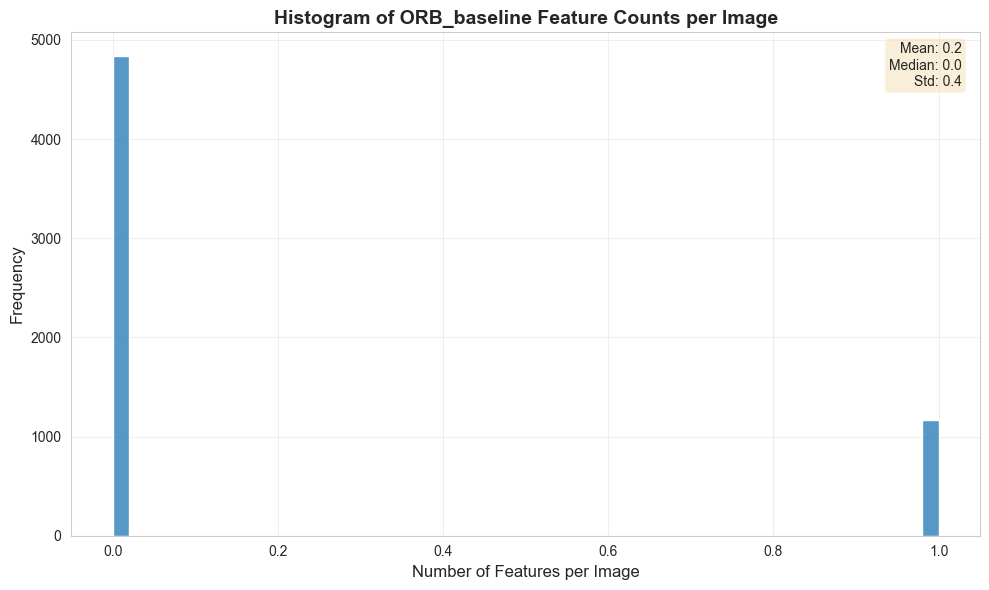

Total images: 6000
Images with 0 features: 4835
Images with features: 1165
Total features extracted: 1165
Extracting ORB features...
Done in 2.02s


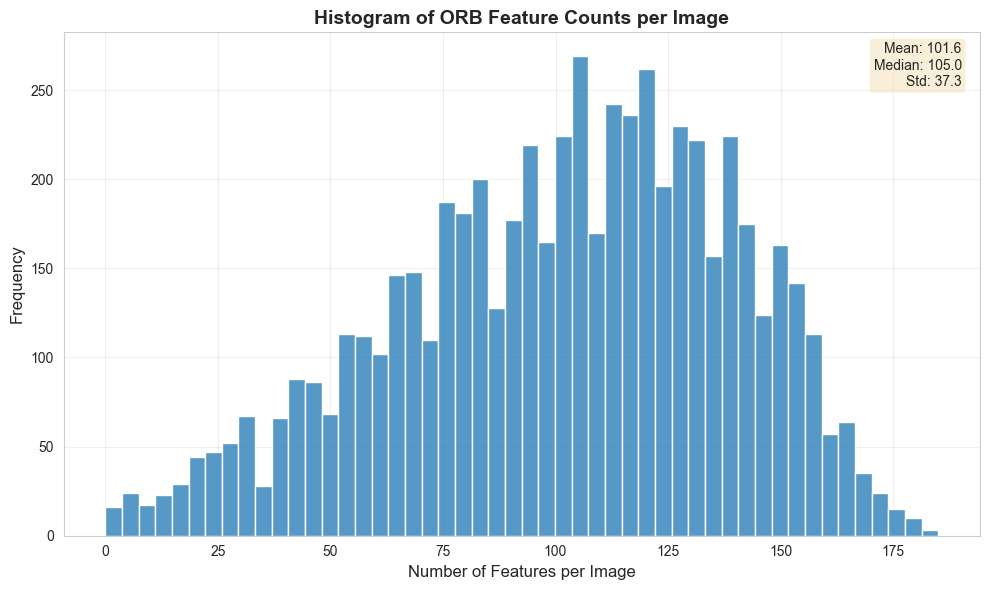

Total images: 6000
Images with 0 features: 8
Images with features: 5992
Total features extracted: 609393
Extracting SIFT_baseline features...
Done in 5.21s


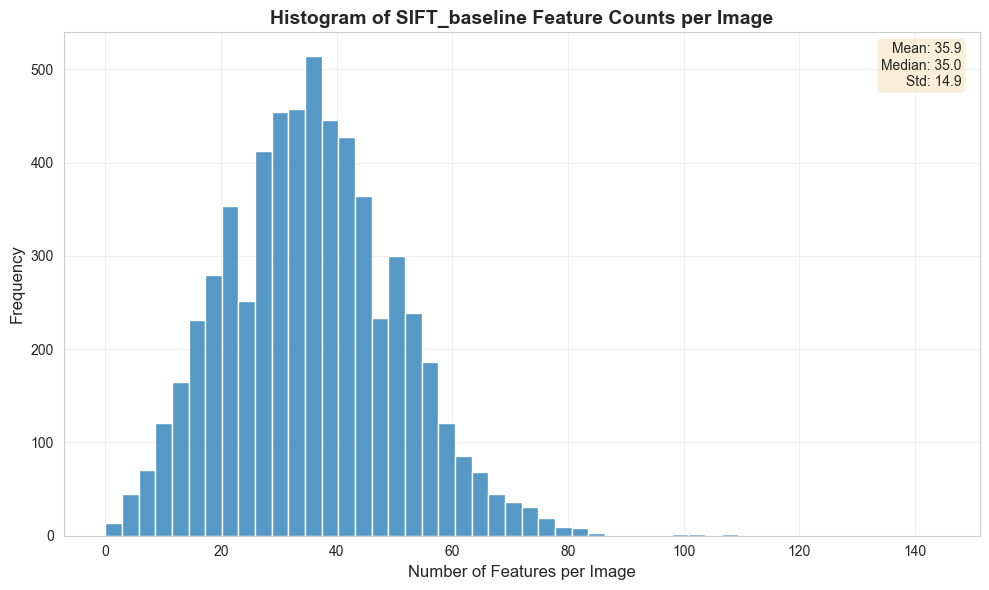

Total images: 6000
Images with 0 features: 5
Images with features: 5995
Total features extracted: 215140
Extracting SIFT features...
Done in 13.49s


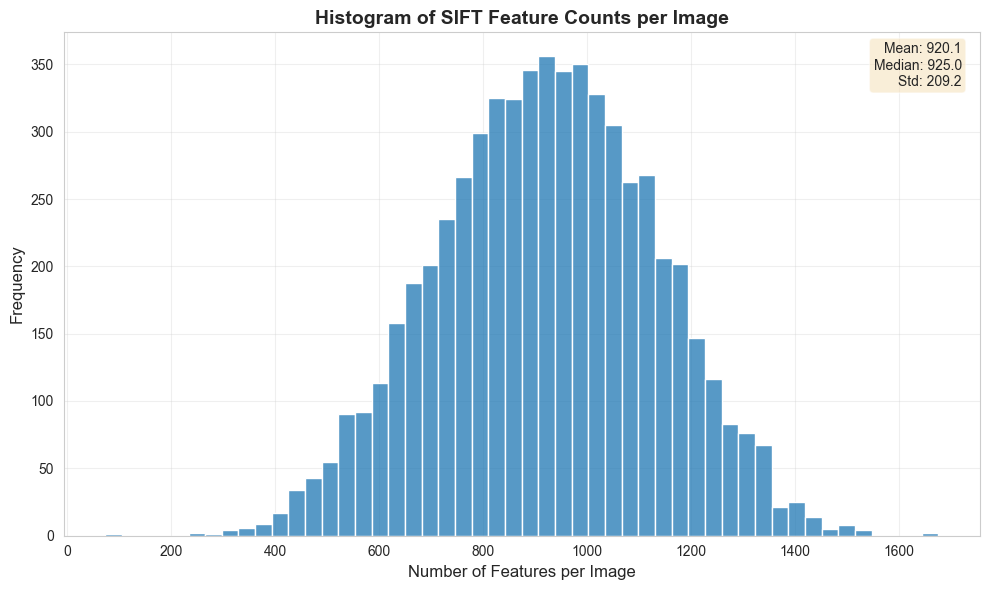

Total images: 6000
Images with 0 features: 0
Images with features: 6000
Total features extracted: 5520369


In [5]:

def plot_feature_counts(X_train, method):
    features = extract_features(X_train, method=method)

    # Count features per image
    feature_counts = []
    for des in features:
        if des is None:
            feature_counts.append(0)
        else:
            feature_counts.append(len(des))

    # Create histogram of feature counts
    sns.histplot(feature_counts, bins=50)
    plt.xlabel('Number of Features per Image', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Histogram of {method} Feature Counts per Image', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Add statistics text
    mean_count = np.mean(feature_counts)
    median_count = np.median(feature_counts)
    std_count = np.std(feature_counts)
    stats_text = f'Mean: {mean_count:.1f}\nMedian: {median_count:.1f}\nStd: {std_count:.1f}'
    plt.text(0.98, 0.98, stats_text, transform=plt.gca().transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"Total images: {len(feature_counts)}")
    print(f"Images with 0 features: {sum(1 for x in feature_counts if x == 0)}")
    print(f"Images with features: {sum(1 for x in feature_counts if x > 0)}")
    print(f"Total features extracted: {sum(feature_counts)}")

for method in ['ORB_baseline', 'ORB', 'SIFT_baseline', 'SIFT']:
    plot_feature_counts(X_train, method)

Visualizing keypoints for: TinyImageNet100_2026/n09193705/images/n09193705_337.JPEG


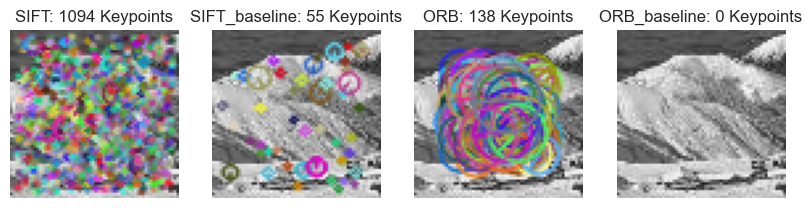

In [6]:
# Visualization: SIFT vs ORB Keypoints

def visualize_keypoints(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    fig, ax = plt.subplots(1, 4, figsize=(10, 5))
    
    for i, method in enumerate(['SIFT', 'SIFT_baseline', 'ORB', 'ORB_baseline']):
        extractor = get_extractor(method)
        kp = extractor.detect(gray, None)
        img_kp = cv2.drawKeypoints(gray, kp, img.copy(), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        img_kp = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)
        ax[i].imshow(img_kp)
        ax[i].set_title(f"{method}: {len(kp)} Keypoints")
        ax[i].axis('off')
    plt.show()

# Select a random training image
sample_img = random.choice(X_train)
print(f"Visualizing keypoints for: {sample_img}")

# Compare feature extraction side by side 
visualize_keypoints(sample_img)

## Encoding Pipelines
We define two classes: `BoWEncoder` and `FisherVectorEncoder`. 

The BoW Encoder groups together local descriptors into a histogram of "visual words", grouping similar local features using K-means. `k=100` for 15 classes means we have ~35 visual words per class.

The FV Encoder expands beyond just counting the occurence of visual words to capturing the mean and variance of the descriptors, and how that varies from modes of a Gaussian Mixture Model (GMM). It also captures the probability distribution to avoid having to make a binary choice about a visual word: this ambiguity helps limit the effect of noise in the data

We apply PCA first to make the computation more efficient by reducing the dimensionality and to make sure the dimensions are independent, allowing us to use the diagonal covariance matrix for further computational efficiency.

In [7]:
class BoWEncoder:
    def __init__(self, k=500):
        self.k = k
        self.kmeans = KMeans(n_clusters=k, n_init=3, random_state=random_state)
        self.scaler = StandardScaler()
        
    def fit(self, descriptors_list, descriptors_for_training):
        print(f"Training BoW Codebook (K={self.k})...")
        self.kmeans.fit(descriptors_for_training)
        
    def transform(self, descriptors_list):
        histograms = []
        for des in descriptors_list:
            if des is None or len(des) == 0:
                histograms.append(np.zeros(self.k))
            else:
                words = self.kmeans.predict(des)
                hist, _ = np.histogram(words, bins=range(self.k+1))
                histograms.append(hist)
        return np.array(histograms)
    
class FisherVectorEncoder:
    def __init__(self, k=128, pca_dim=64):
        self.k = k
        self.pca_dim = pca_dim
        self.gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=random_state)
        self.pca = PCA(n_components=pca_dim)
        
    def fit(self, descriptors_list, descriptors_for_training):
        # RootSIFT Normalization 
        descriptors_for_training /= (descriptors_for_training.sum(axis=1, keepdims=True) + 1e-7)
        descriptors_for_training = np.sqrt(descriptors_for_training)

        print(f"Fitting PCA (128 -> {self.pca_dim})...")
        self.pca.fit(descriptors_for_training)
        pca_des = self.pca.transform(descriptors_for_training)
        
        print(f"Training GMM (K={self.k})...")
        self.gmm.fit(pca_des)
        
    def transform(self, descriptors_list):
        print("Encoding Fisher Vectors...")
        
        weights = self.gmm.weights_
        means = self.gmm.means_
        covars = self.gmm.covariances_
        
        sigmas = np.sqrt(covars) # Shape (K, D)
        
        # Reshape to (K, 1) to broadcast against (K, D)
        inv_sqrt_weights = (1.0 / np.sqrt(weights)).reshape(-1, 1)
        
        fvs = []
        
        for des in descriptors_list:
            if des is None or len(des) == 0:
                fvs.append(np.zeros(2 * self.k * self.pca_dim))
                continue
            
            # RootSIFT on the fly (L1 normalize -> Sqrt)
            des /= (des.sum(axis=1, keepdims=True) + 1e-7)
            des = np.sqrt(des)
            
            # PCA projection
            x = self.pca.transform(des) # Shape: (N_features, D)
            n_features = x.shape[0]
            
            # Get posteriors (soft assignments)
            gamma = self.gmm.predict_proba(x) # Shape: (N_features, K)
                        
            # Calculate x_norm: (N, K, D), Mean Vector (u_k) and Covariance Vector (v_k)
            x_norm = (x[:, None, :] - means[None, :, :]) / sigmas[None, :, :]
            fv_means = np.sum(gamma[:, :, None] * x_norm, axis=0)
            fv_covars = np.sum(gamma[:, :, None] * (x_norm**2 - 1), axis=0)
            
            # Fisher Information Matrix Normalization
            fv_means = fv_means * inv_sqrt_weights
            fv_covars = fv_covars * inv_sqrt_weights
            
            # Flatten and concatenate
            fv = np.hstack([fv_means.flatten(), fv_covars.flatten()])
            
            # Normalize by number of features, power normalization and l2 normalization
            fv /= n_features
            fv = np.sign(fv) * np.sqrt(np.abs(fv))
            norm = np.linalg.norm(fv)
            if norm > 0:
                fv /= norm
                
            fvs.append(fv)
            
        return np.array(fvs)

## Model Training and Evaluation

We train a `LinearSVM` model on the full training set and evaluate it on the test set. 

We run the full training and evaluation loop on 6 combinations of the feature extractor and encoders. In the process we identify the optimal `C` regularisation parameter for the model using `GridSearch` over a list of strong regularisation values [1e-6, 1e-5, 1e-4, 1e-3] to control for the noisy features. 

SIFT + Fisher Values and a C value of 1e-5 was the top performing model with a score of 52%. The baseline implementation of ORB was barely better than random chance, so the effect of the feature extractor, encoder and hyperparameter optimisation is very evident.

The confusion matrix highlights some common fail points: 

- A complete inability to identify a plunger (18% accuracy)
- Some clear confusion between acorns, cauliflowers and peppers (possibly paying more attention to background leaves than foreground objects)
- The single most confused choice was between alps and coastlines, which suggest it can identify landscape boundaries but struggles to distinguish between blue skies and blue sea

Significant questions remain about how well this model can generalise to new data, as some of those signals suggest a brittle model.

In [8]:
# Implent grid search for the best C value for each model

results = []

experiments = [
    {'name': 'ORB_baseline + BoW', 'feature': 'ORB_baseline', 'encoder': 'BoW'},
    {'name': 'ORB + BoW', 'feature': 'ORB', 'encoder': 'BoW'},
    {'name': 'SIFT_baseline + BoW', 'feature': 'SIFT_baseline', 'encoder': 'BoW'},
    {'name': 'SIFT + BoW', 'feature': 'SIFT', 'encoder': 'BoW'},
    {'name': 'SIFT_baseline + FV', 'feature': 'SIFT_baseline', 'encoder': 'FV'},
    {'name': 'SIFT + FV', 'feature': 'SIFT', 'encoder': 'FV'}
]

for exp in experiments:
    print(f"\n{'='*40}\nStarting Experiment: {exp['name']}\n{'='*40}")
    
    # Feature Extraction
    train_des = extract_features(X_train, method=exp['feature'])
    test_des = extract_features(X_test, method=exp['feature'])
    
    train_des_optim = optimize_descriptors(train_des, limit=200000)
    if train_des_optim is None:
        print("Fitting Failed: No Features.")
        continue

    if exp['encoder'] == 'BoW':
        encoder = BoWEncoder(k=500)
    else:
        encoder = FisherVectorEncoder(k=128) 
        
    encoder.fit(train_des, train_des_optim)
    X_train_enc = encoder.transform(train_des)
    X_test_enc = encoder.transform(test_des)
    
    # Scaling (Important for SVM)
    scaler = StandardScaler()
    X_train_enc = scaler.fit_transform(X_train_enc)
    X_test_enc = scaler.transform(X_test_enc)
    
    print(f"Encoded Feature Shape: {X_train_enc.shape}")
    
    # Classification (SVM Grid Search)
    print("Training SVM...")
    param_grid = {'C': [1e-6, 1e-5, 1e-4, 1e-3]} 
        
    svm = GridSearchCV(LinearSVC(random_state=random_state), param_grid, cv=3, n_jobs=-1, verbose=1)
    svm.fit(X_train_enc, y_train)
    
    # Evaluation
    y_pred = svm.predict(X_test_enc)
    acc = accuracy_score(y_test, y_pred)
    print(f"Experiment {exp['name']} Accuracy: {acc*100:.2f}%")
    
    results.append({
        'Experiment': exp['name'],
        'Accuracy': acc,
        'Best Params': svm.best_params_,
        'Model': svm,
        'y_pred': y_pred
    })


Starting Experiment: ORB_baseline + BoW
Extracting ORB_baseline features...
Done in 1.41s
Extracting ORB_baseline features...
Done in 0.44s
Training BoW Codebook (K=500)...
Encoded Feature Shape: (6000, 500)
Training SVM...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Experiment ORB_baseline + BoW Accuracy: 7.20%

Starting Experiment: ORB + BoW
Extracting ORB features...
Done in 1.98s
Extracting ORB features...
Done in 0.53s
Training BoW Codebook (K=500)...
Encoded Feature Shape: (6000, 500)
Training SVM...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Experiment ORB + BoW Accuracy: 18.13%

Starting Experiment: SIFT_baseline + BoW
Extracting SIFT_baseline features...
Done in 5.30s
Extracting SIFT_baseline features...
Done in 1.34s
Training BoW Codebook (K=500)...
Encoded Feature Shape: (6000, 500)
Training SVM...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Experiment SIFT_baseline + BoW Accuracy: 24.53%

Starting Experiment: SIFT + BoW
Extr

,Experiment,Accuracy,Best Params
0,ORB_baseline + BoW,0.072000,{'C': 0.001}
1,ORB + BoW,0.181333,{'C': 1e-05}
2,SIFT_baseline + BoW,0.245333,{'C': 1e-05}
3,SIFT + BoW,0.406000,{'C': 0.0001}
4,SIFT_baseline + FV,0.351333,{'C': 1e-06}
5,SIFT + FV,0.529333,{'C': 1e-05}


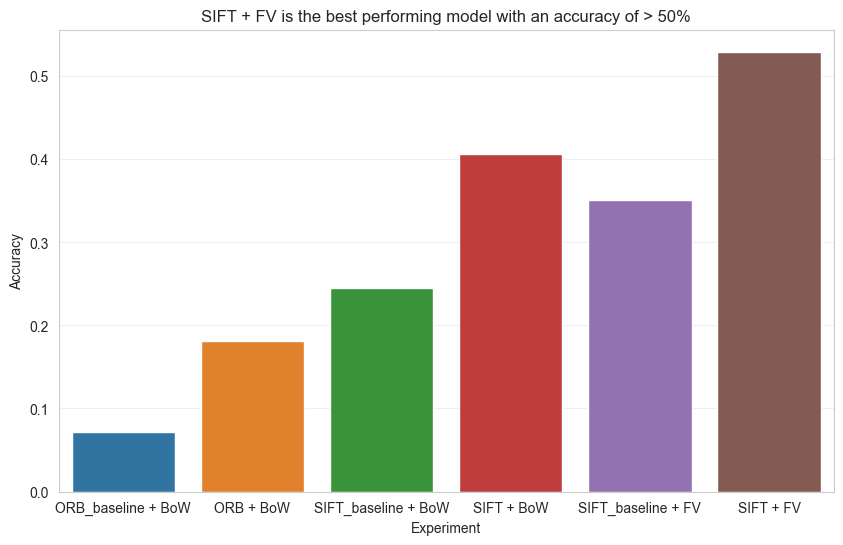

In [9]:
# Performance Comparison 
results_df = pd.DataFrame(results)
display(results_df[['Experiment', 'Accuracy', 'Best Params']])

sns.barplot(x='Experiment', y='Accuracy', data=results_df, hue = 'Experiment', palette='tab10', legend=False)
plt.title('SIFT + FV is the best performing model with an accuracy of > 50%')
plt.ylabel('Accuracy')
plt.show()

/var/folders/sx/dpbc0wjj0f16b60xvwr6dtcw0000gn/T/ipykernel_89615/2453898417.py:8: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(x='param_C', y='mean_test_score', data=results_df, hue = colors, palette=colors, legend=False)


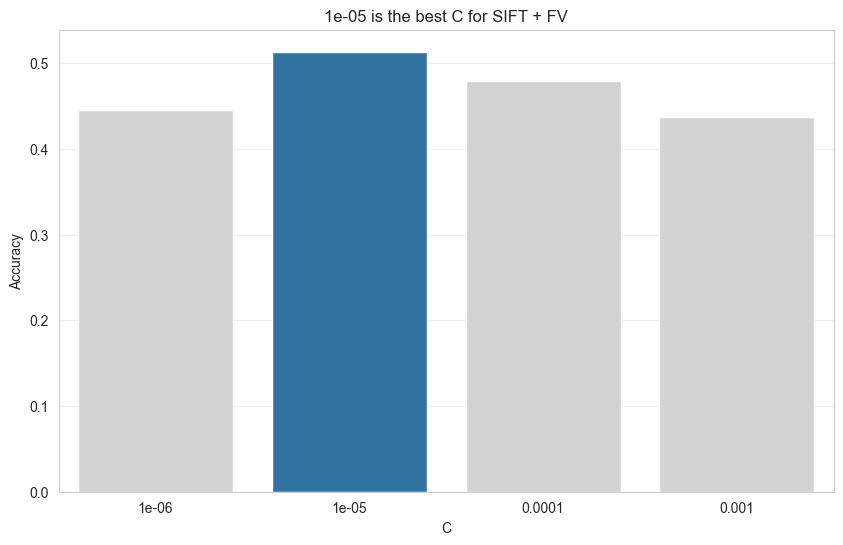

In [10]:
# Display grid search scores for SIFT + Fisher
bow_res = next((r for r in results if r['Experiment'] == 'SIFT + FV'), None)

results_df = pd.DataFrame(bow_res['Model'].cv_results_)
highlight_C = 1e-05
colors = [primary_color if x == highlight_C else 'lightgrey' for x in results_df['param_C']]

sns.barplot(x='param_C', y='mean_test_score', data=results_df, hue = colors, palette=colors, legend=False)
plt.title('1e-05 is the best C for SIFT + FV')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.show()

Best Model: SIFT + FV


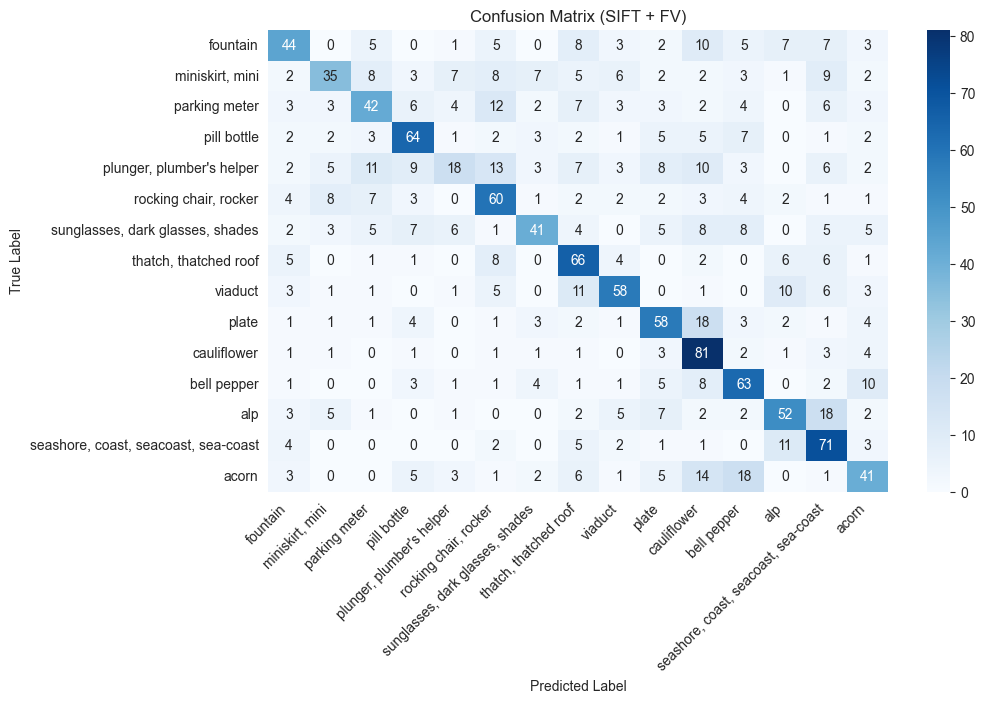

In [11]:
# 3. Best Model Confusion Matrix
best_result = max(results, key=lambda x: x['Accuracy'])
print(f"Best Model: {best_result['Experiment']}")

cm = confusion_matrix(y_test, best_result['y_pred'], labels=sorted(label_map.keys()))
class_names = [label_map[k] for k in sorted(label_map.keys())]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix ({best_result['Experiment']})")
plt.xticks(rotation=45, ha='right')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

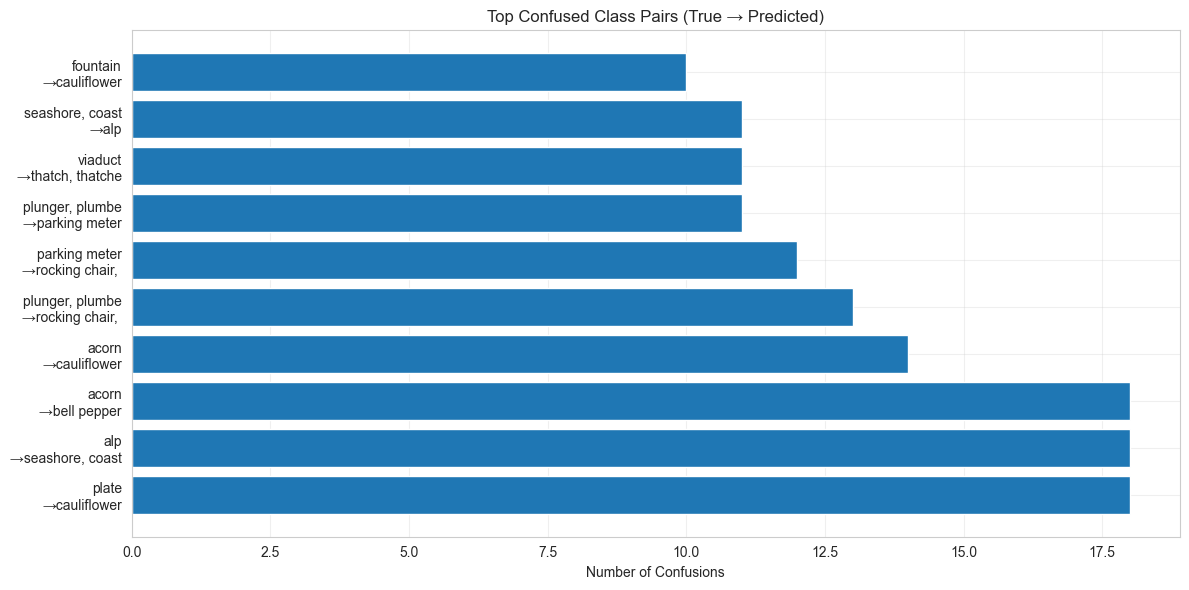

In [12]:
def analyze_confusion_patterns(y_true, y_pred, class_names, top_k=10):
    """Identify the most confused class pairs."""
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)  # Zero out correct predictions
    
    # Find top confused pairs
    confused_pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if cm[i, j] > 0:
                confused_pairs.append((class_names[i], class_names[j], cm[i, j]))
    
    confused_pairs.sort(key=lambda x: x[2], reverse=True)
    
    # Visualize top confused pairs
    fig, ax = plt.subplots(figsize=(12, 6))
    pairs = [f"{p[0][:15]}\n→{p[1][:15]}" for p in confused_pairs[:top_k]]
    counts = [p[2] for p in confused_pairs[:top_k]]
    ax.barh(range(len(pairs)), counts)
    ax.set_yticks(range(len(pairs)))
    ax.set_yticklabels(pairs)
    ax.set_xlabel('Number of Confusions')
    ax.set_title('Top Confused Class Pairs (True → Predicted)')
    plt.tight_layout()
    plt.show()
    
    return confused_pairs[:top_k]

def visualize_confused_classes(X_test, y_true, y_pred, label_map, 
                                true_class_name, pred_class_name, n_examples=5):
    """Compare misclassified images with correct examples from both classes."""
    
    # Reverse lookup: get class ID from class name
    name_to_id = {v: k for k, v in label_map.items()}
    true_class_id = name_to_id[true_class_name]
    pred_class_id = name_to_id[pred_class_name]
    
    # Convert to numpy arrays if needed
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    
    # Find misclassified: true class predicted as pred class
    misclassified_indices = np.where((y_true_arr == true_class_id) & 
                                      (y_pred_arr == pred_class_id))[0]
    
    # Find correctly classified from both classes
    correct_true_indices = np.where((y_true_arr == true_class_id) & 
                                     (y_pred_arr == true_class_id))[0]
    correct_pred_indices = np.where((y_true_arr == pred_class_id) & 
                                     (y_pred_arr == pred_class_id))[0]
    
    # Create figure
    fig, axes = plt.subplots(3, n_examples, figsize=(3*n_examples, 9))
    fig.suptitle(f'Why is "{true_class_name}" confused with "{pred_class_name}"?', fontsize=14)
    
    row_labels = [
        f'Correct\n{true_class_name[:15]}',
        f'Misclassified\n({true_class_name[:10]}→{pred_class_name[:10]})',
        f'Correct\n{pred_class_name[:15]}'
    ]
    
    index_sets = [correct_true_indices, misclassified_indices, correct_pred_indices]
    
    for row, (indices, label) in enumerate(zip(index_sets, row_labels)):
        axes[row, 0].set_ylabel(label, fontsize=10, rotation=0, ha='right', va='center')
        
        for col in range(n_examples):
            if col < len(indices):
                img_path = X_test[indices[col]]
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    axes[row, col].imshow(img)
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

class_names = [label_map[k] for k in sorted(label_map.keys())]
top_confused = analyze_confusion_patterns(y_test, best_result['y_pred'], class_names)

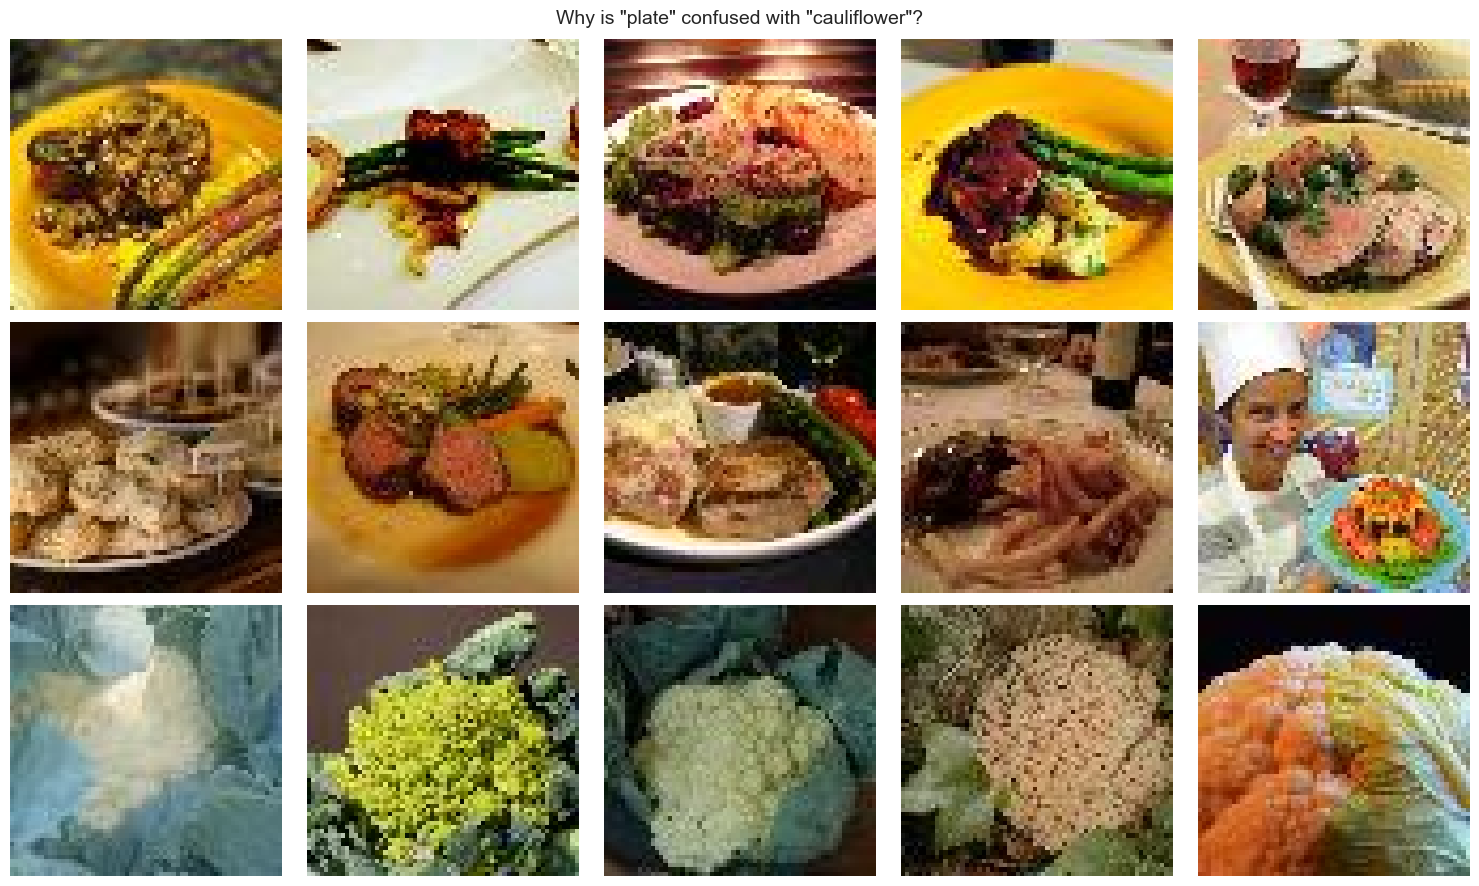

In [ ]:
# Show the most confused classes as a visual reminder of the model's weaknesses (backgrounds are too influential?)


true_class_name, pred_class_name, _ = top_confused[0]
visualize_confused_classes(X_test, y_test, best_result['y_pred'], label_map,
                            true_class_name, pred_class_name)

## References

1. Chufeng Tang. (2019). Tiny ImageNet Challenge. https://kaggle.com/competitions/thu-deep-learning.
2. David Lowe. (2004). Distinctive Image Features from Scale-Invariant Keypoints. https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf
3. E. Rublee, V. Rabaud, K. Konolige and G. Bradski, "ORB: An efficient alternative to SIFT or SURF," 2011 International Conference on Computer Vision, Barcelona, Spain, 2011, pp. 2564-2571, doi: 10.1109/ICCV.2011.6126544.
4. Csurka, Gabriela & Dance, Christopher & Fan, Lixin & Willamowski, Jutta & Bray, Cédric. (2004). Visual categorization with bags of keypoints. Work Stat Learn Comput Vision, ECCV. Vol. 1. 
5. Sánchez, J., Perronnin, F., Mensink, T. et al. Image Classification with the Fisher Vector: Theory and Practice. Int J Comput Vis 105, 222–245 (2013). https://doi.org/10.1007/s11263-013-0636-x
6. Cortes, C., Vapnik, V. Support-vector networks. Mach Learn 20, 273–297 (1995). https://doi.org/10.1007/BF00994018

### AI Declaration

I used Cursor as the IDE for this project and used their 'Tab' model throughout: just intelligent autocomplete on code I've been writing. It mostly just speeds up simple tasks. I relied heavily on Gemini for the implementation of the Fisher Vector encoder.